# #Task 1 — Data Exploration with Pandas

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
# Loading the dataset and printing the first 5 rows

df = pd.read_csv("students.csv")
print("Dataset loaded\n")
print("First 5 rows:")
df.head()

Dataset loaded

First 5 rows:


,name,math,science,english,history,pe,attendance_pct,study_hours_per_day,passed
0,Alice,88,92,76,80,95,92,4.5,1
1,Bob,42,55,48,50,60,65,1.2,0
2,Charlie,75,70,80,68,88,85,3.0,1
3,Diana,95,98,91,89,97,98,6.0,1
4,Eve,38,42,50,45,55,58,0.8,0


In [ ]:
#Dataset information

print("Shape (rows, columns):", df.shape)

print("\nData Types:\n")
print(df.dtypes)

Shape (rows, columns): (15, 9)

Data Types:

name                       str
math                     int64
science                  int64
english                  int64
history                  int64
pe                       int64
attendance_pct           int64
study_hours_per_day    float64
passed                   int64
dtype: object


In [14]:
# Summary statistics for numerical columns

print("Summary Statistics:")
print(df.describe())

Summary Statistics:
            math    science    english    history         pe  attendance_pct  \
count  15.000000  15.000000  15.000000  15.000000  15.000000       15.000000   
mean   65.000000  66.733333  66.200000  63.400000  74.800000       75.800000   
std    20.060622  18.967893  17.773174  16.936014  16.657045       14.722189   
min    30.000000  35.000000  40.000000  28.000000  45.000000       50.000000   
25%    51.500000  53.500000  49.000000  53.500000  61.000000       63.500000   
50%    65.000000  65.000000  70.000000  62.000000  75.000000       78.000000   
75%    80.000000  77.000000  81.000000  73.500000  89.000000       86.500000   
max    95.000000  98.000000  91.000000  92.000000  97.000000       98.000000   

       study_hours_per_day     passed  
count            15.000000  15.000000  
mean              2.893333   0.600000  
std               1.658944   0.507093  
min               0.500000   0.000000  
25%               1.650000   0.000000  
50%               2

In [17]:
# Pass/Fail count

print("Pass/Fail Count:\n")

pass_fail_counts = df['passed'].value_counts()
#print(pass_fail_counts)

print("\nPassed:", pass_fail_counts.get(1, 0))
print("Failed:", pass_fail_counts.get(0, 0))

Pass/Fail Count:


Passed: 9
Failed: 6


In [18]:
# Average scores for passing and failing students

subject_cols = ['math', 'science', 'english', 'history', 'pe']

# Passing students
pass_avg = df[df['passed'] == 1][subject_cols].mean()

# Failing students
fail_avg = df[df['passed'] == 0][subject_cols].mean()

print("Average Scores (Passing Students):\n")
print(pass_avg)

print("\nAverage Scores (Failing Students):\n")
print(fail_avg)

Average Scores (Passing Students):

math       78.222222
science    78.555556
english    79.111111
history    73.444444
pe         86.000000
dtype: float64

Average Scores (Failing Students):

math       45.166667
science    49.000000
english    46.833333
history    48.333333
pe         58.000000
dtype: float64


In [ ]:
# Creating temporary average column
df['avg_score'] = df[subject_cols].mean(axis=1)

# Find top student
top_student = df.loc[df['avg_score'].idxmax()]

print("Top Student Based on Average:\n")
print(top_student)

Top Student Based on Average:

name                   Diana
math                      95
science                   98
english                   91
history                   89
pe                        97
attendance_pct            98
study_hours_per_day      6.0
passed                     1
avg_score               94.0
Name: 3, dtype: object


#  #Task 2 — Data Visualization with Matplotlib

In [20]:
subject_cols = ['math', 'science', 'english', 'history', 'pe']

# Add average score column
df['avg_score'] = df[subject_cols].mean(axis=1)

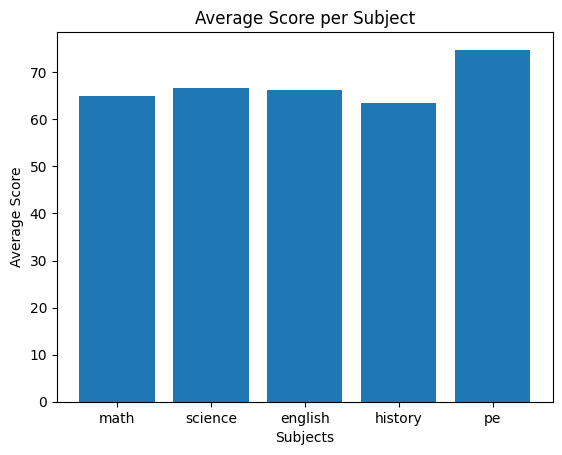

In [ ]:
#Bar plot of average scores per subject

avg_scores = df[subject_cols].mean()

plt.figure()
plt.bar(subject_cols, avg_scores)

plt.title("Average Score per Subject")
plt.xlabel("Subjects")
plt.ylabel("Average Score")

plt.savefig("plot1_bar.png")
plt.show()

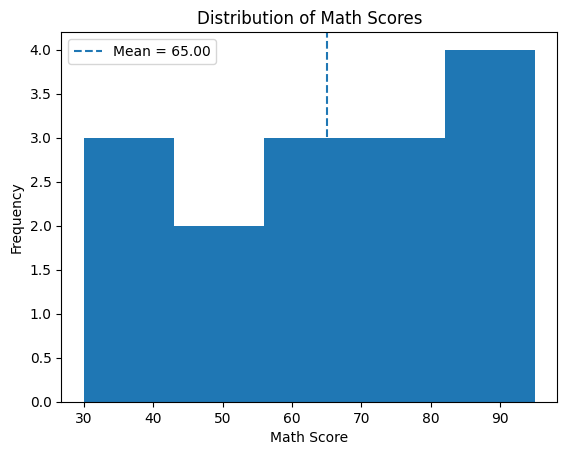

In [22]:
# Histogram of math scores with mean line

math_scores = df['math']
mean_math = math_scores.mean()

plt.figure()
plt.hist(math_scores, bins=5)

plt.axvline(mean_math, linestyle='--', label=f"Mean = {mean_math:.2f}")

plt.title("Distribution of Math Scores")
plt.xlabel("Math Score")
plt.ylabel("Frequency")
plt.legend()

plt.savefig("plot2_histogram.png")
plt.show()

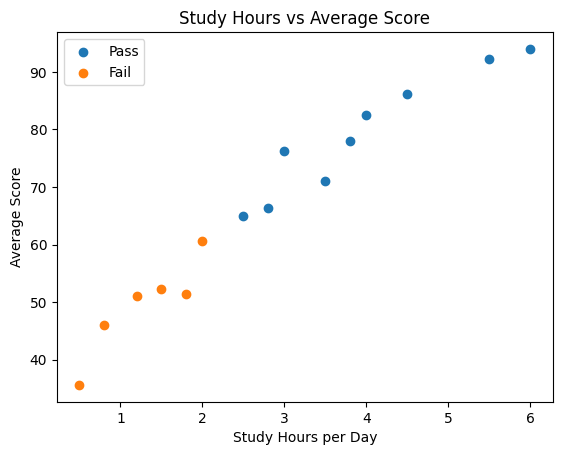

In [23]:
#scatter plot of study hours vs average score, colored by pass/fail

pass_df = df[df['passed'] == 1]
fail_df = df[df['passed'] == 0]

plt.figure()

plt.scatter(pass_df['study_hours_per_day'], pass_df['avg_score'], label="Pass")
plt.scatter(fail_df['study_hours_per_day'], fail_df['avg_score'], label="Fail")

plt.title("Study Hours vs Average Score")
plt.xlabel("Study Hours per Day")
plt.ylabel("Average Score")
plt.legend()

plt.savefig("plot3_scatterplot.png")
plt.show()

C:\Users\rkp\AppData\Local\Temp\ipykernel_5044\1960779767.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([pass_attendance, fail_attendance], labels=['Pass', 'Fail'])


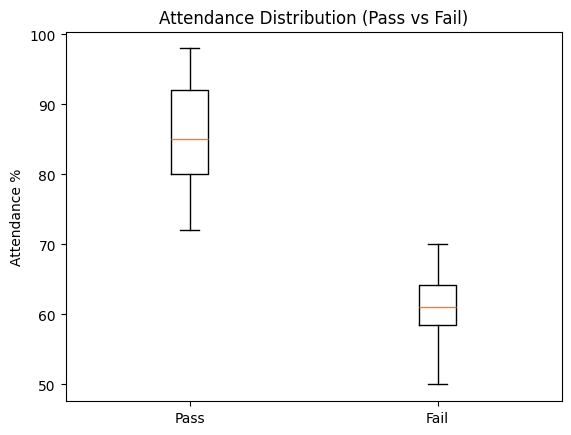

In [24]:
# Boxplot of attendance percentage for passing vs failing students

pass_attendance = df[df['passed'] == 1]['attendance_pct'].tolist()
fail_attendance = df[df['passed'] == 0]['attendance_pct'].tolist()

plt.figure()

plt.boxplot([pass_attendance, fail_attendance], labels=['Pass', 'Fail'])

plt.title("Attendance Distribution (Pass vs Fail)")
plt.ylabel("Attendance %")

plt.savefig("plot4_boxplot.png")
plt.show()

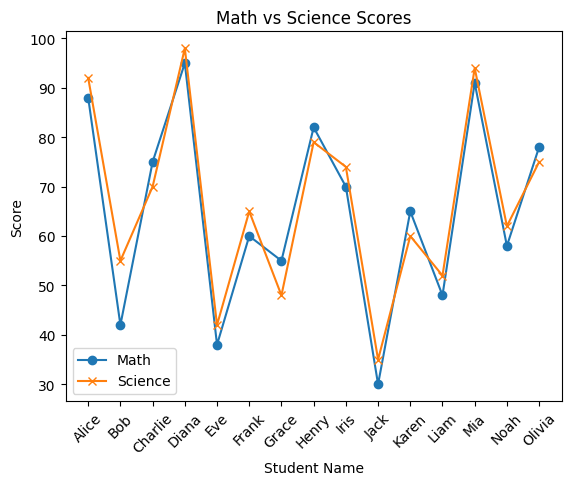

In [26]:
#line plot of math and science scores for each student

names = df['name']

plt.figure()

plt.plot(names, df['math'], marker='o', label="Math")
plt.plot(names, df['science'], marker='x', label="Science")

plt.title("Math vs Science Scores")
plt.xlabel("Student Name")
plt.ylabel("Score")

plt.xticks(rotation=45)
plt.legend()

plt.savefig("plot5_lineplot.png")
plt.show()

#  #Task 3 — Data Visualization with Seaborn

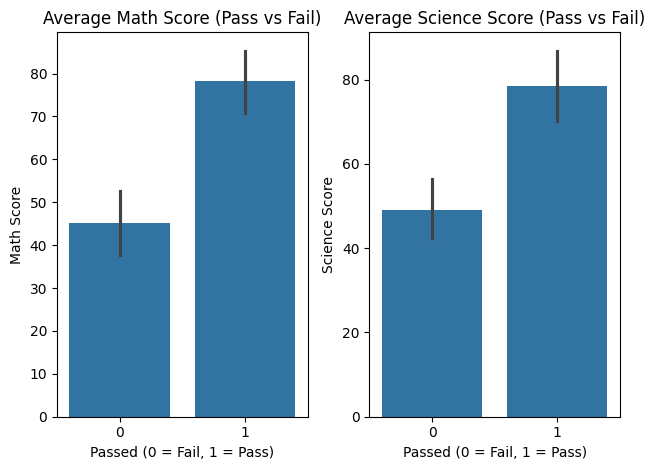

In [27]:
#seaborn bar plot of average math and science scores for passing vs failing students

plt.figure()

# Subplot 1 → Math
plt.subplot(1, 2, 1)
sns.barplot(data=df, x='passed', y='math')
plt.title("Average Math Score (Pass vs Fail)")
plt.xlabel("Passed (0 = Fail, 1 = Pass)")
plt.ylabel("Math Score")

# Subplot 2 → Science
plt.subplot(1, 2, 2)
sns.barplot(data=df, x='passed', y='science')
plt.title("Average Science Score (Pass vs Fail)")
plt.xlabel("Passed (0 = Fail, 1 = Pass)")
plt.ylabel("Science Score")

plt.tight_layout()
plt.savefig("plot6_seaborn_bar.png")
plt.show()

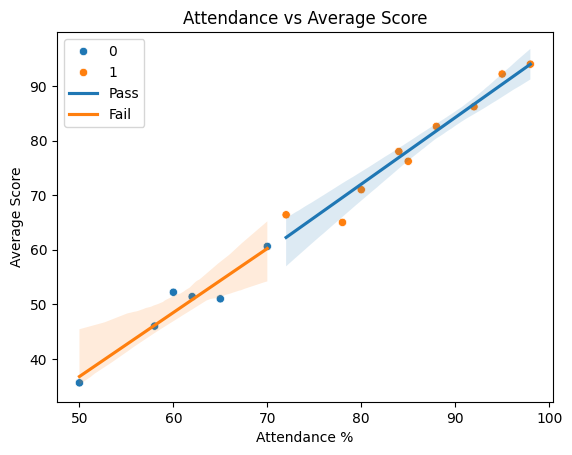

In [28]:
#seaborn scatter plot of attendance percentage vs average score, colored by pass/fail with regression lines

plt.figure()

# Scatter plot with hue
sns.scatterplot(data=df, x='attendance_pct', y='avg_score', hue='passed')

# Regression line for Pass
sns.regplot(
    data=df[df['passed'] == 1],
    x='attendance_pct',
    y='avg_score',
    scatter=False,
    label='Pass'
)

# Regression line for Fail
sns.regplot(
    data=df[df['passed'] == 0],
    x='attendance_pct',
    y='avg_score',
    scatter=False,
    label='Fail'
)

plt.title("Attendance vs Average Score")
plt.xlabel("Attendance %")
plt.ylabel("Average Score")
plt.legend()

plt.savefig("plot7_seaborn_scatterplot.png")
plt.show()

In [ ]:
# Seaborn made it easier to create grouped and styled plots with less code,
# especially for handling categories like Pass vs Fail automatically.
# In contrast, Matplotlib required more manual work for grouping and styling,
# but gave more control over low-level customization.

#  #Task 4 — Machine Learning with scikit-learn